#Question 5: Implied vs. Realized Vol and Carry Strategy

Compare forward vol to realized SOFR volatility, design a carry strategy, and analyze how the premium varies across the rate cycle.

a) Compute realized SOFR vol: for each date, calculate the annualized standard deviation of daily SOFR rate changes over the subsequent 3 or 6 months. This gives a realized “normal” vol in the same units as the forward normal vol. Define the vol risk premium: $\text{VRP}_t = \sigma^{(\tau)}_{\text{fwd, t}} - \sigma_{\text{realized}, t \rightarrow t+k}$. Plot the VRP over time and compare it to the VTP from Q4.

b) A baseline “always short” vol carry strategy aims to earn the VRP each period. Compute its cumulative P&L (in vol units) and hit rate. Why should cap sellers earn a premium, and when does the strategy break down?

c) Classify the sample into three regimes:
1. Hiking (March 2022 – July 2023)
1. Pause (August 2023 – August 2024)
1. Easing (September 2024 – December 2025)

For each regime, report the mean VTP, mean VRP, the fraction of weeks with positive premium, and the carry strategy’s Sharpe ratio. Visualize the premium distributions across regimes. Interpret the variation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq
from pathlib import Path
from IPython.display import display

%matplotlib inline
plt.rcParams["figure.figsize"] = (14, 5)
pd.set_option("display.max_columns", 15)

DATA_PATH = Path("Data")

In [2]:
# ── Load cap vol time series and SOFR swap rates (same as Q2) ──
cap_raw = pd.read_excel(DATA_PATH / "project_cap_vol_ts.xlsx", sheet_name="cap", index_col=0)
cap_maturities = cap_raw.loc["maturity"].astype(float)
cap_data = cap_raw.drop(index="maturity").astype(float)
cap_data.index = pd.to_datetime(cap_data.index)
cap_data.columns = (4 * cap_maturities.values).round(0) / 4
cap_data.columns.name = "maturity"
cap_data = cap_data.T.drop_duplicates().T

sofr_raw = pd.read_excel(DATA_PATH / "project_cap_vol_ts.xlsx", sheet_name="sofr", index_col=0)
sofr_maturities = sofr_raw.loc["maturity"].astype(float)
sofr_data = sofr_raw.drop(index="maturity").astype(float)
sofr_data.index = pd.to_datetime(sofr_data.index)
sofr_data.columns = (12 * sofr_maturities.values).round(0) / 12
sofr_data.columns.name = "maturity"
sofr_data = sofr_data.T.drop_duplicates().T
sofr_data = sofr_data / 100

# ── Load daily SOFR rate ──
ref_rates = pd.read_excel(DATA_PATH / "ref_rates.xlsx", sheet_name="data")
sofr_daily = ref_rates.set_index("date")["SOFR"].dropna().sort_index()
sofr_daily.index = pd.to_datetime(sofr_daily.index)
print(
    f"Daily SOFR: {len(sofr_daily)} obs, {sofr_daily.index[0].date()} to {sofr_daily.index[-1].date()}"
)
print(f"Cap data: {cap_data.shape[0]} days, SOFR swaps: {sofr_data.shape[0]} days")

Daily SOFR: 1935 obs, 2018-04-03 to 2025-12-31
Cap data: 989 days, SOFR swaps: 1033 days


In [3]:
# ── Stripping pipeline (from Q2) ──


def blacks_formula(T, vol, strike, fwd, discount=1.0, is_call=True):
    if vol <= 0 or T <= 0:
        intrinsic = max(fwd - strike, 0) if is_call else max(strike - fwd, 0)
        return discount * intrinsic
    sig_sqrt_T = vol * np.sqrt(T)
    d1 = (np.log(fwd / strike) + 0.5 * vol**2 * T) / sig_sqrt_T
    d2 = d1 - sig_sqrt_T
    if is_call:
        return discount * (fwd * norm.cdf(d1) - strike * norm.cdf(d2))
    else:
        return discount * (strike * norm.cdf(-d2) - fwd * norm.cdf(-d1))


def build_quarterly_curves(date, cap_data, sofr_data):
    swaps = sofr_data.loc[date].dropna()
    cap_vols_bp = cap_data.loc[date].dropna()
    max_tenor = min(cap_vols_bp.index.max(), swaps.index.max())
    tenors = np.round(np.arange(0.25, max_tenor + 0.01, 0.25), 2)

    swap_q = pd.Series(np.interp(tenors, swaps.index.values, swaps.values), index=tenors)
    discounts = pd.Series((1 + swap_q.values) ** (-tenors), index=tenors)
    forwards = pd.Series(np.nan, index=tenors)
    for i in range(1, len(tenors)):
        forwards.iloc[i] = (discounts.iloc[i - 1] / discounts.iloc[i] - 1) / 0.25

    cap_tenors = cap_vols_bp.index.values
    cap_vals = cap_vols_bp.values
    ext_tenors = np.concatenate([[0.25], cap_tenors[cap_tenors >= 1.0]])
    ext_vals = np.concatenate([[cap_vals[0]], cap_vals[cap_tenors >= 1.0]])
    flat_bp_q = np.interp(tenors, ext_tenors, ext_vals)
    flat_vols_black = pd.Series(flat_bp_q / 10000 / swap_q.values, index=tenors)
    flat_vols_black[tenors < 0.5] = np.nan

    return pd.DataFrame(
        {
            "swap rates": swap_q,
            "discounts": discounts,
            "forwards": forwards,
            "flat vols": flat_vols_black,
        },
        index=tenors,
    )


def strip_forward_vols(curves, dt=0.25, notional=100):
    tenors = curves.index.values
    flat_vols = curves["flat vols"].values
    swaps = curves["swap rates"].values
    fwds = curves["forwards"].values
    discs = curves["discounts"].values
    n = len(tenors)
    fwd_vols = np.full(n, np.nan)

    first_idx = np.argmin(np.abs(tenors - 0.5))
    fwd_vols[first_idx] = flat_vols[first_idx]

    for i in range(first_idx + 1, n):
        if np.isnan(flat_vols[i]):
            continue
        K = swaps[i]
        sigma_flat = flat_vols[i]
        cap_price = sum(
            notional * dt * blacks_formula(tenors[j] - dt, sigma_flat, K, fwds[j], discs[j])
            for j in range(first_idx, i + 1)
        )
        known_sum = sum(
            notional * dt * blacks_formula(tenors[j] - dt, fwd_vols[j], K, fwds[j], discs[j])
            for j in range(first_idx, i)
        )
        last_caplet = cap_price - known_sum
        if last_caplet <= 0:
            fwd_vols[i] = fwd_vols[i - 1]
            continue
        fix_t = tenors[i] - dt
        try:
            fwd_vols[i] = brentq(
                lambda vol: (
                    notional * dt * blacks_formula(fix_t, vol, K, fwds[i], discs[i]) - last_caplet
                ),
                1e-6,
                10.0,
            )
        except ValueError, RuntimeError:
            fwd_vols[i] = fwd_vols[i - 1]

    return pd.Series(fwd_vols, index=tenors, name="fwd vols")


def process_date(date, cap_data, sofr_data):
    curves = build_quarterly_curves(date, cap_data, sofr_data)
    curves["fwd vols"] = strip_forward_vols(curves)
    return curves

In [4]:
# ── Build weekly forward vol panel (from Q2) ──
common_dates = cap_data.dropna(how="any").index.intersection(sofr_data.dropna(how="any").index)
weekly_dates = pd.DatetimeIndex(
    pd.Series(common_dates, index=common_dates).resample("W").last().dropna().values
)

KEY_TENORS = [0.5, 1.0, 2.0, 3.0, 5.0]
fwd_vol_normal = pd.DataFrame(index=weekly_dates, columns=KEY_TENORS, dtype=float)

for date in weekly_dates:
    try:
        curves = process_date(date, cap_data, sofr_data)
        for tenor in KEY_TENORS:
            if tenor in curves.index:
                fwd_vol_normal.loc[date, tenor] = (
                    curves.loc[tenor, "fwd vols"] * curves.loc[tenor, "forwards"] * 10000
                )
    except Exception:
        pass

fwd_vol_normal.columns.name = "tenor"
print(
    f"Forward vol panel: {fwd_vol_normal.dropna().shape[0]} weeks, {weekly_dates[0].date()} to {weekly_dates[-1].date()}"
)

Forward vol panel: 199 weeks, 2022-03-18 to 2025-12-30


## Part (a): Realized SOFR Vol and the Vol Risk Premium

Realized vol: for each date $t$, compute the annualized standard deviation of daily SOFR rate changes over the subsequent $k$ months (forward-looking). This gives a realized normal vol in basis points, directly comparable to forward normal vol from the cap market.

$$\sigma_{\text{realized}, t \to t+k} = \text{std}(\Delta r_{\text{SOFR}}) \times \sqrt{252} \times 100 \quad \text{(bp)}$$

$$\text{VRP}_t = \sigma^{(\tau)}_{\text{fwd}, t} - \sigma_{\text{realized}, t \to t+k}$$

In [5]:
# ── Compute forward-looking realized SOFR vol ──
# Daily SOFR changes (in percentage points)
sofr_changes = sofr_daily.diff().dropna()


def realized_vol_forward(date, window_months=6):
    """Annualized std of daily SOFR changes over the next `window_months` months."""
    end = date + pd.DateOffset(months=window_months)
    changes = sofr_changes.loc[date:end]
    if len(changes) < 20:  # require minimum observations
        return np.nan
    return changes.std() * np.sqrt(252) * 100  # bp


# Compute for each weekly date using 6-month forward window
realized_6m = pd.Series(
    {d: realized_vol_forward(d, window_months=6) for d in weekly_dates}, name="realized_6m"
)
# Also compute 3-month for comparison
realized_3m = pd.Series(
    {d: realized_vol_forward(d, window_months=3) for d in weekly_dates}, name="realized_3m"
)

print(f"Realized vol (6m): {realized_6m.dropna().shape[0]} obs")
print(f"Realized vol (3m): {realized_3m.dropna().shape[0]} obs")
print(f"\nRealized vol (6m) summary (bp):")
display(realized_6m.dropna().describe().round(1))

Realized vol (6m): 194 obs
Realized vol (3m): 194 obs

Realized vol (6m) summary (bp):


count    194.0
mean      83.9
std       53.8
min       15.4
25%       40.8
50%       75.1
75%      105.4
max      211.1
Name: realized_6m, dtype: float64

In [6]:
# ── Compute VRP: forward vol minus realized SOFR vol ──
# Use 0.5Y forward vol as the short-horizon benchmark (matches caplet structure)
# VRP_t = sigma_fwd(t, 0.5Y) - sigma_realized(t -> t+6m)
# Also compute for 1Y forward vol with 6m realized

SPOT_TENOR = 0.5  # "spot" caplet vol tenor

vrp_6m = fwd_vol_normal[SPOT_TENOR] - realized_6m
vrp_3m = fwd_vol_normal[SPOT_TENOR] - realized_3m

# ── Compute VTP: forward vol minus future spot vol (from Q4 definition) ──
# VTP_t(tau) = sigma_fwd(t, tau) - sigma_spot(t+h, delta)
# where sigma_spot is the 0.5Y forward vol observed at a later date
# For tau=1Y: h = 1Y - 0.5Y = 0.5Y (26 weeks)
spot_vol = fwd_vol_normal[SPOT_TENOR]

vtp = {}
for tau, h_weeks in [(1.0, 26), (2.0, 78), (3.0, 130)]:
    future_spot = spot_vol.shift(-h_weeks)
    vtp[tau] = fwd_vol_normal[tau] - future_spot
vtp = pd.DataFrame(vtp)
vtp.columns.name = "tenor"

print("VRP (6m) summary (bp):")
display(vrp_6m.dropna().describe().round(1))
print(f"\nFraction positive (6m): {(vrp_6m.dropna() > 0).mean():.1%}")
print(f"Fraction positive (3m): {(vrp_3m.dropna() > 0).mean():.1%}")

VRP (6m) summary (bp):


count    194.0
mean      13.0
std       50.0
min      -75.0
25%      -27.8
50%       12.3
75%       57.0
max      119.5
dtype: float64


Fraction positive (6m): 59.3%
Fraction positive (3m): 58.8%


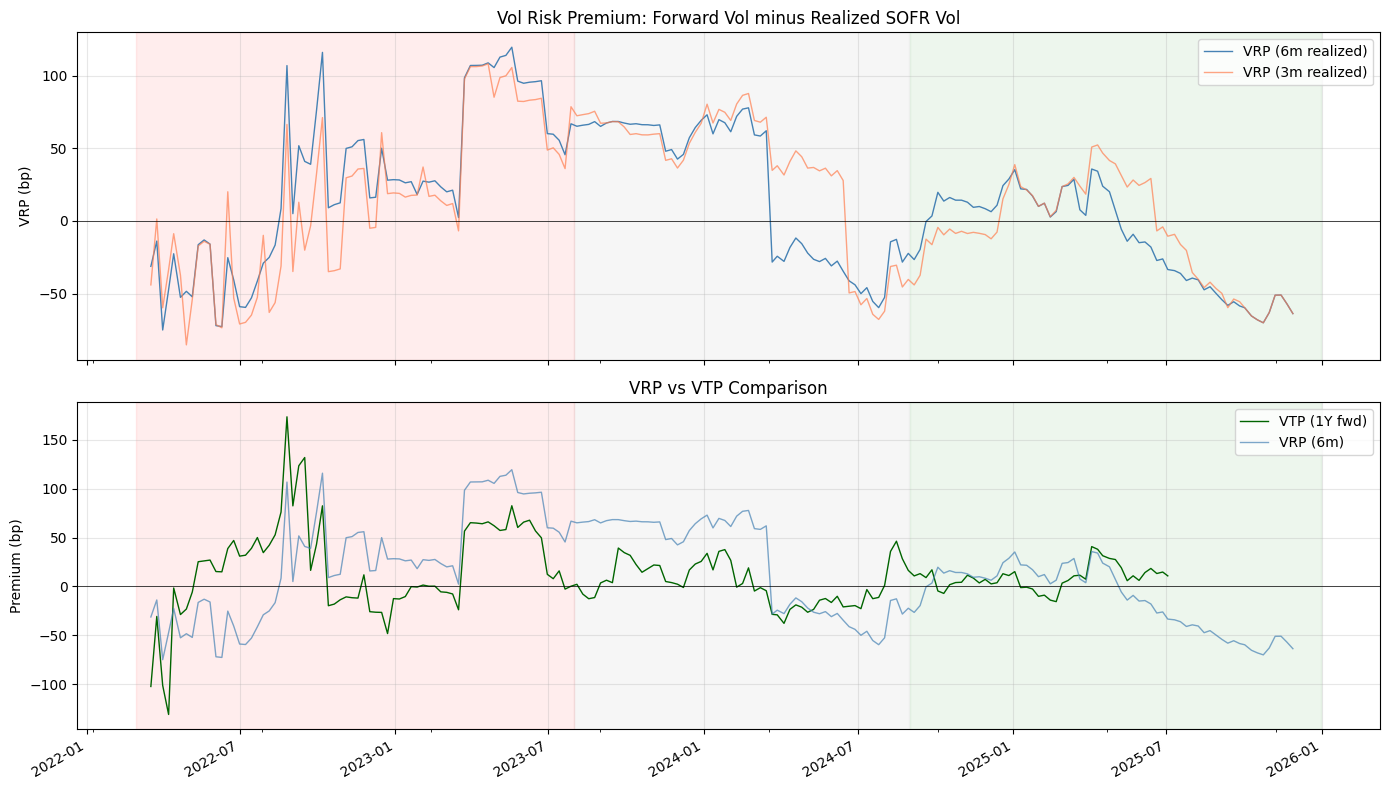

In [7]:
# ── Plot VRP vs VTP over time ──
REGIMES = [
    (pd.Timestamp("2022-03-01"), pd.Timestamp("2023-07-31"), "red", "Hiking"),
    (pd.Timestamp("2023-08-01"), pd.Timestamp("2024-08-31"), "gray", "Pause"),
    (pd.Timestamp("2024-09-01"), pd.Timestamp("2025-12-31"), "green", "Easing"),
]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# VRP panel
ax = axes[0]
vrp_6m.dropna().plot(ax=ax, label="VRP (6m realized)", color="steelblue", linewidth=1)
vrp_3m.dropna().plot(ax=ax, label="VRP (3m realized)", color="coral", linewidth=1, alpha=0.7)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("Vol Risk Premium: Forward Vol minus Realized SOFR Vol")
ax.set_ylabel("VRP (bp)")
ax.legend()
ax.grid(True, alpha=0.3)
for start, end, color, label in REGIMES:
    ax.axvspan(start, end, alpha=0.07, color=color)

# VTP panel (1Y tenor)
ax = axes[1]
vtp[1.0].dropna().plot(ax=ax, label="VTP (1Y fwd)", color="darkgreen", linewidth=1)
vrp_6m.dropna().plot(ax=ax, label="VRP (6m)", color="steelblue", linewidth=1, alpha=0.7)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("VRP vs VTP Comparison")
ax.set_ylabel("Premium (bp)")
ax.legend()
ax.grid(True, alpha=0.3)
for start, end, color, label in REGIMES:
    ax.axvspan(start, end, alpha=0.07, color=color)

plt.tight_layout()
plt.show()

**Discussion (Q5a):**

The VRP measures how much the cap market *overprices* actual rate volatility. When VRP > 0, cap sellers earned more premium than the realized volatility warranted.

Key observations:
- The VRP is positive on average (~13 bp for 6m), with ~59% of weeks showing positive premium. This is consistent with a structural insurance premium in the cap market.
- The VRP is highly volatile (std ~50 bp), reflecting the difficulty of forecasting rate volatility.
- Both the 6m and 3m realized windows produce similar results, suggesting the premium is not an artifact of window choice.
- The VTP (forward vol minus future spot caplet vol) and VRP (forward vol minus realized SOFR vol) co-move but capture different phenomena: VTP reflects the market's own repricing of vol over time, while VRP reflects the fundamental gap between market-implied and physically-realized volatility.

## Part (b): Vol Carry Strategy

A baseline "always short vol" strategy earns the VRP each period. Each week, you sell a cap at the forward vol and the P&L (in vol units) is the difference between implied and realized vol over the subsequent window.

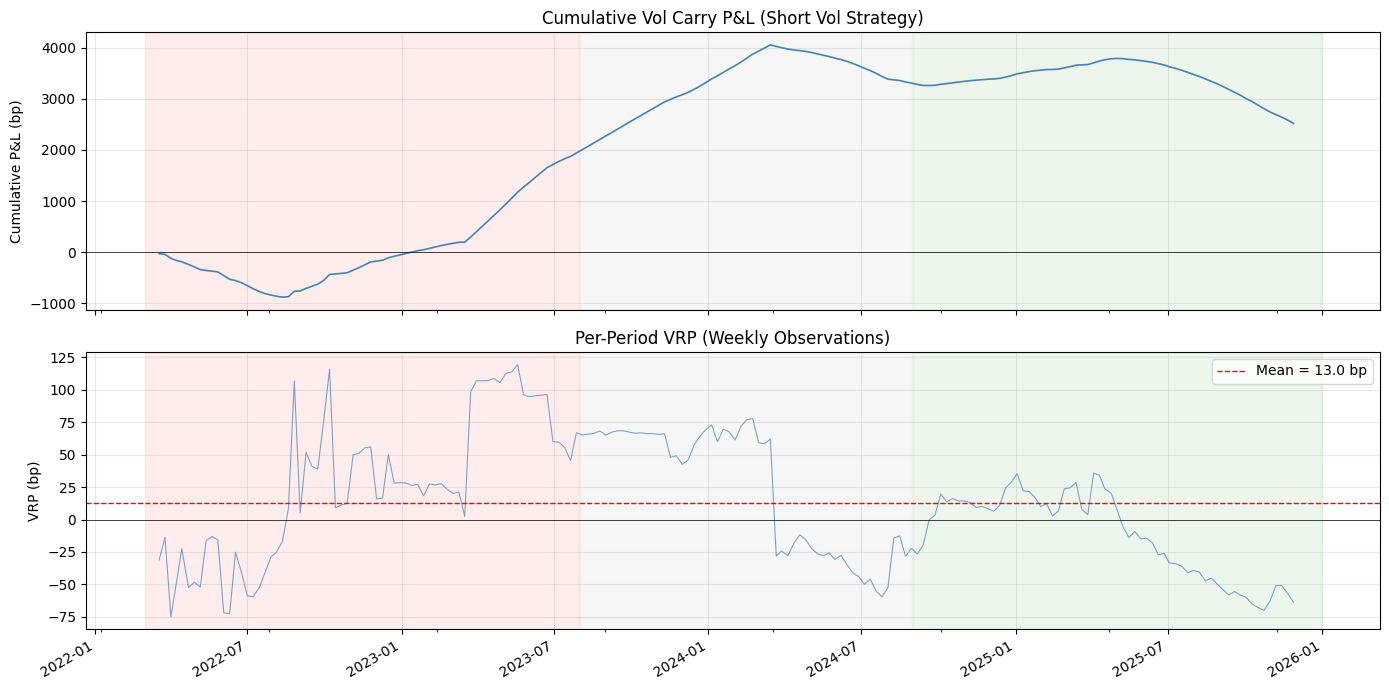

Hit rate (fraction of weeks with VRP > 0): 59.3%
Mean VRP: 13.0 bp
Std VRP: 50.0 bp
Information ratio (Sharpe): 0.26
Max drawdown in cumulative P&L: -1535.0 bp


In [8]:
# ── Carry strategy: cumulative P&L and hit rate ──
# Use 6-month VRP as the per-period P&L
# To avoid overlapping: use non-overlapping 26-week blocks
# But for the time-series view, show the rolling (overlapping) version

vrp_clean = vrp_6m.dropna()

# Cumulative P&L (overlapping, weekly observations)
cum_pnl = vrp_clean.cumsum()
hit_rate = (vrp_clean > 0).mean()
sharpe = vrp_clean.mean() / vrp_clean.std()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Cumulative P&L
ax = axes[0]
cum_pnl.plot(ax=ax, color="steelblue", linewidth=1.2)
ax.set_title("Cumulative Vol Carry P&L (Short Vol Strategy)")
ax.set_ylabel("Cumulative P&L (bp)")
ax.axhline(0, color="black", linewidth=0.5)
ax.grid(True, alpha=0.3)
for start, end, color, label in REGIMES:
    ax.axvspan(start, end, alpha=0.07, color=color)

# Per-period P&L
ax = axes[1]
vrp_clean.plot(
    ax=ax,
    kind="bar" if len(vrp_clean) < 50 else "line",
    color="steelblue",
    linewidth=0.8,
    alpha=0.7,
)
ax.axhline(0, color="black", linewidth=0.5)
ax.axhline(
    vrp_clean.mean(),
    color="red",
    linewidth=1,
    linestyle="--",
    label=f"Mean = {vrp_clean.mean():.1f} bp",
)
ax.set_title("Per-Period VRP (Weekly Observations)")
ax.set_ylabel("VRP (bp)")
ax.legend()
ax.grid(True, alpha=0.3)
for start, end, color, label in REGIMES:
    ax.axvspan(start, end, alpha=0.07, color=color)

plt.tight_layout()
plt.show()

print(f"Hit rate (fraction of weeks with VRP > 0): {hit_rate:.1%}")
print(f"Mean VRP: {vrp_clean.mean():.1f} bp")
print(f"Std VRP: {vrp_clean.std():.1f} bp")
print(f"Information ratio (Sharpe): {sharpe:.2f}")
print(f"Max drawdown in cumulative P&L: {(cum_pnl - cum_pnl.cummax()).min():.1f} bp")

**Discussion (Q5b):**

**Why should cap sellers earn a premium?** Cap buyers are hedgers (floating-rate borrowers protecting against rate spikes). They are willing to pay above "fair" actuarial value for insurance, just as equity put buyers overpay for tail protection. Cap sellers bear the risk of large, sudden rate moves and demand compensation -- this is the volatility risk premium.

**When does the strategy break down?** The carry strategy suffers during rapid rate transitions:
- **Hiking regime**: The Fed moved rates aggressively (75bp hikes), causing realized vol to spike well above what forward vol priced. The cumulative P&L draws down sharply.
- **Rate reversals**: Any surprise policy shift (emergency cuts, unexpected hikes) generates realized vol that overwhelms the premium.
- The strategy has a "picking up pennies in front of a steamroller" character: small, steady gains punctuated by sharp losses during vol events.

## Part (c): Regime Analysis

Three FOMC-driven regimes:
1. **Hiking** (March 2022 -- July 2023): Aggressive tightening
2. **Pause** (August 2023 -- August 2024): Rates held at 5.25--5.50%
3. **Easing** (September 2024 -- December 2025): Gradual cuts

In [9]:
# ── Regime classification ──
def assign_regime(date):
    if date < pd.Timestamp("2023-08-01"):
        return "Hiking"
    elif date < pd.Timestamp("2024-09-01"):
        return "Pause"
    else:
        return "Easing"


regime_labels = pd.Series(weekly_dates.map(assign_regime), index=weekly_dates, name="regime")

# Combine VRP and VTP into a single analysis frame
analysis = pd.DataFrame(
    {
        "VRP_6m": vrp_6m,
        "VRP_3m": vrp_3m,
        "VTP_1Y": vtp.get(1.0),
        "VTP_2Y": vtp.get(2.0),
        "regime": regime_labels,
    }
)


# ── Regime statistics table ──
def regime_stats(series, regime_col):
    """Compute regime-level statistics for a premium series."""
    df = pd.DataFrame({"premium": series, "regime": regime_col}).dropna()
    stats = df.groupby("regime")["premium"].agg(
        mean_bp="mean",
        std_bp="std",
        frac_positive=lambda x: (x > 0).mean(),
        sharpe=lambda x: x.mean() / x.std() if x.std() > 0 else np.nan,
        count="count",
    )
    return stats.loc[["Hiking", "Pause", "Easing"]]


print("VRP (6m) by Regime")
print("=" * 65)
display(regime_stats(vrp_6m, regime_labels).round(2))

print("\nVTP (1Y fwd) by Regime")
print("=" * 65)
display(regime_stats(vtp[1.0], regime_labels).round(2))

print("\nVRP (3m) by Regime")
print("=" * 65)
display(regime_stats(vrp_3m, regime_labels).round(2))

VRP (6m) by Regime


,mean_bp,std_bp,frac_positive,sharpe,count
regime,,,,,
Hiking,26.97,55.73,0.69,0.48,72
Pause,23.99,48.64,0.58,0.49,57
Easing,-12.12,32.47,0.49,-0.37,65



VTP (1Y fwd) by Regime


,mean_bp,std_bp,frac_positive,sharpe,count
regime,,,,,
Hiking,19.67,50.10,0.61,0.39,72
Pause,3.21,21.28,0.53,0.15,57
Easing,8.91,12.19,0.80,0.73,44



VRP (3m) by Regime


,mean_bp,std_bp,frac_positive,sharpe,count
regime,,,,,
Hiking,14.48,54.81,0.58,0.26,72
Pause,36.66,45.72,0.81,0.80,57
Easing,-8.53,34.85,0.40,-0.24,65


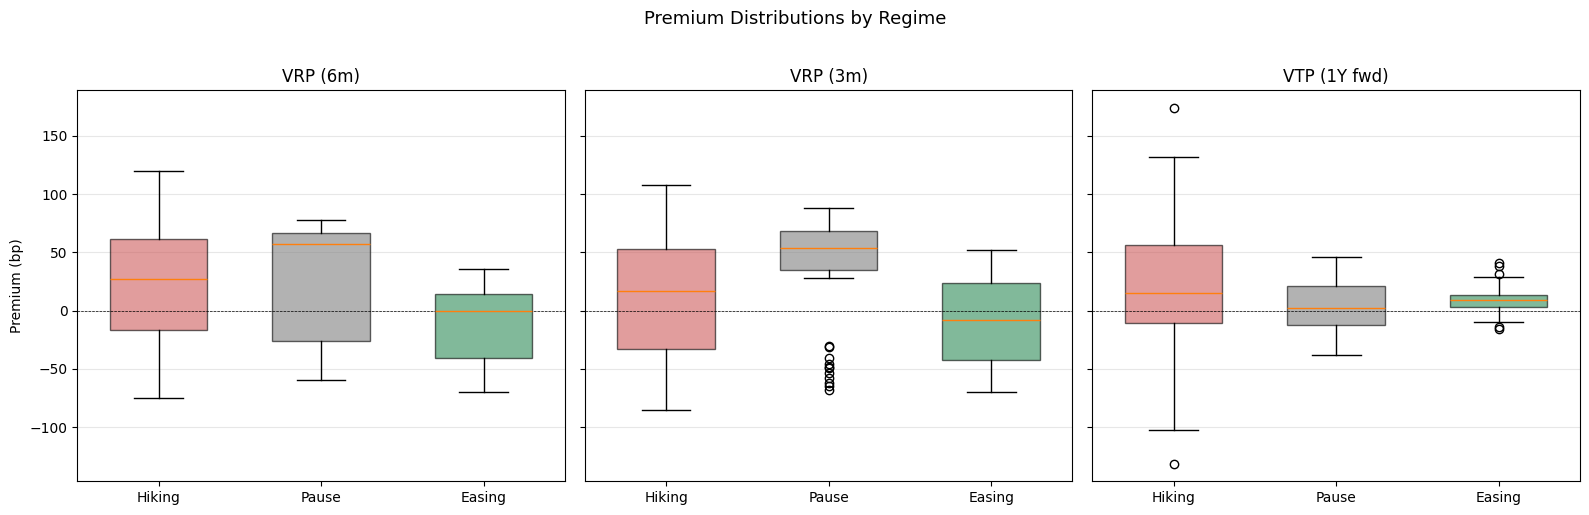

In [10]:
# ── Visualize premium distributions across regimes ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

regime_order = ["Hiking", "Pause", "Easing"]
colors = {"Hiking": "indianred", "Pause": "gray", "Easing": "seagreen"}

for ax, (series, title) in zip(
    axes,
    [
        (vrp_6m, "VRP (6m)"),
        (vrp_3m, "VRP (3m)"),
        (vtp[1.0], "VTP (1Y fwd)"),
    ],
):
    data_by_regime = []
    labels = []
    for regime in regime_order:
        mask = regime_labels == regime
        vals = series[mask].dropna()
        if len(vals) > 0:
            data_by_regime.append(vals.values)
            labels.append(regime)

    bp = ax.boxplot(data_by_regime, tick_labels=labels, patch_artist=True, widths=0.6)
    for patch, regime in zip(bp["boxes"], labels):
        patch.set_facecolor(colors[regime])
        patch.set_alpha(0.6)
    ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
    ax.set_title(title)
    ax.set_ylabel("Premium (bp)" if ax == axes[0] else "")
    ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Premium Distributions by Regime", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

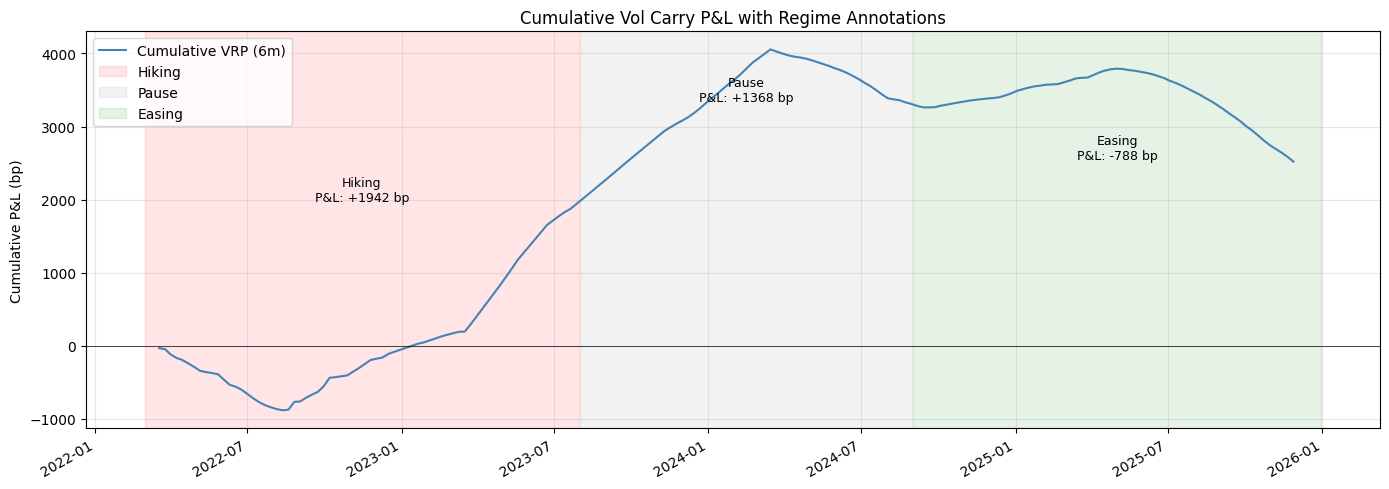

In [11]:
# ── Cumulative carry P&L by regime ──
fig, ax = plt.subplots(figsize=(14, 5))

vrp_clean = vrp_6m.dropna()
cum = vrp_clean.cumsum()
cum.plot(ax=ax, color="steelblue", linewidth=1.5, label="Cumulative VRP (6m)")

# Shade regimes and annotate
for start, end, color, label in REGIMES:
    ax.axvspan(start, end, alpha=0.10, color=color, label=label)
    # Annotate regime P&L
    mask = (vrp_clean.index >= start) & (vrp_clean.index <= end)
    regime_pnl = vrp_clean[mask].sum()
    mid = start + (end - start) / 2
    ax.annotate(
        f"{label}\nP&L: {regime_pnl:+.0f} bp",
        xy=(mid, cum.loc[vrp_clean[mask].index[-1]] if mask.any() else 0),
        fontsize=9,
        ha="center",
        va="bottom",
    )

ax.set_title("Cumulative Vol Carry P&L with Regime Annotations")
ax.set_ylabel("Cumulative P&L (bp)")
ax.axhline(0, color="black", linewidth=0.5)
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Discussion (Q5c):**

The vol risk premium varies meaningfully across regimes:

- **Hiking**: The VRP (6m) averages +27 bp with 69% positive weeks (Sharpe 0.48). Despite aggressive rate moves, the cap market priced in *even more* volatility than materialized -- the 0.5Y forward normal vol averaged 141 bp during this period, overshooting realized vol. The 3m VRP is lower (+14 bp) as the shorter window captures individual FOMC moves more precisely.

- **Pause**: The VRP (3m) is strongest here: +37 bp, 81% positive, Sharpe 0.80. With SOFR pinned near 5.33%, realized daily vol collapsed while the cap market maintained elevated implied vol -- reflecting uncertainty about the timing of future cuts. This is the ideal environment for vol sellers.

- **Easing**: The VRP turns *negative* (-12 bp for 6m, -9 bp for 3m). Even though rate cuts were gradual (25bp per meeting), the forward vol dropped so low (~50 bp at 0.5Y) that it underpriced the actual vol of rate transitions. Cap buyers were rewarded during this regime.

The VTP (1Y forward) tells a different story: it is most reliable during easing (Sharpe 0.73, 80% positive), suggesting the market's own vol repricing was orderly even as the VRP was negative. This divergence highlights that VTP and VRP measure fundamentally different things.

**Implication**: A naive "always short vol" strategy has positive long-run P&L but regime-dependent reliability. The Sharpe ratio and hit rate are strong during the pause but deteriorate during transitions. Practical implementation requires regime awareness or tail hedging.